# MODELADO IRAIA

Cosas que hacer:
- primero train test y luego escalar y dummies
- ANalizar los coeficientes y odds ratios
- Aplico PCA???

In [1]:
# Cargar librerias
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
np.random.seed(0)

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import os

In [2]:
# Cargar datos
df = pd.read_csv("df_limpio_con_clusters.csv")
df_clustering= pd.read_csv("df_modelado_clustering.csv", sep=",", low_memory=False)
df_tiempo = pd.read_csv("datos_meteorologicos_2023.csv")


In [3]:
#Tamaño
print(f"Df_Limpio: {df.shape}")
print(f"Df_Tiempo: {df_tiempo.shape}")

Df_Limpio: (51707, 47)
Df_Tiempo: (3285, 22)


In [4]:
#Tipo de variables
print(df.dtypes)
print(df_tiempo.dtypes)

booked_at                          object
checkin_time                       object
lead_time                           int64
lenght_of_stay                      int64
checkin_month                      object
checkin_day                        object
adult_count                         int64
child_count                         int64
origin                             object
travel_agency_name                 object
requested_category                 object
requested_category_name            object
asset                              object
asset_type                         object
brand                              object
available_units                     int64
business_segment                   object
rate                               object
rate_group_name                    object
rate_type                          object
completed_entry_forms_count       float64
all_entry_forms_completed          object
returning_inhabitant               object
recurrence                        

In [5]:
#Visualizar las primeras 10 filas:
print(f"Df_limpio: {df.head(10)}")
print(f"Df_tiempo: {df_tiempo.head(10)}")


Df_limpio:              booked_at         checkin_time  lead_time  lenght_of_stay  \
0  2022-11-26 16:10:00  2023-01-01 12:00:00         36               1   
1  2022-12-21 17:27:00  2023-01-01 13:09:00         11               9   
2  2022-09-21 19:46:00  2023-01-01 15:00:00        102               6   
3  2022-09-24 12:09:00  2023-01-01 15:00:00         99               1   
4  2022-10-18 07:12:00  2023-01-01 15:00:00         75               1   
5  2022-11-25 17:50:00  2023-01-01 15:00:00         37               1   
6  2022-11-26 04:10:00  2023-01-01 15:00:00         36               2   
7  2022-12-02 20:02:00  2023-01-01 15:00:00         30               1   
8  2022-12-04 23:18:00  2023-01-01 15:00:00         28               2   
9  2022-12-11 12:51:00  2023-01-01 15:00:00         21               7   

  checkin_month checkin_day  adult_count  child_count           origin  \
0       January      Sunday            1            0  channel_manager   
1       January      Sunda

Quedarnos con las variables del df que no tiene relacion con cancelaciones.

In [6]:
columnas_sin_inf_cancelaciones = [
    'checkin_time','lead_time','lenght_of_stay','checkin_month','checkin_day','adult_count','child_count',
    'origin','requested_category','asset','asset_type','business_segment','rate_type',
    'returning_inhabitant','recurrence','libere_community','reservation_net_value',
    'zona_roja_mes','Estacion_Estancia',
    'Estacion_Reserva','estancia_en_festivo','estancia_en_finde','City', 'mes_checkin_numerico',
    'reservation_checkin_month_diff', 'Reserva_Dia_Semana', 'status'
]


df_sin_inf_cancell = df[columnas_sin_inf_cancelaciones]
print(df_sin_inf_cancell)

              checkin_time  lead_time  lenght_of_stay checkin_month  \
0      2023-01-01 12:00:00         36               1       January   
1      2023-01-01 13:09:00         11               9       January   
2      2023-01-01 15:00:00        102               6       January   
3      2023-01-01 15:00:00         99               1       January   
4      2023-01-01 15:00:00         75               1       January   
...                    ...        ...             ...           ...   
51702  2023-12-31 15:00:00         79               1      December   
51703  2023-12-31 15:00:00         79               1      December   
51704  2023-12-31 15:00:00         75               1      December   
51705  2023-12-31 15:00:00         75               1      December   
51706  2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday  

Juntar ambos df-s por (Fecha, Hora, Ciudad)

In [7]:
# Cambiar nombre a la ciudad Donosti (Salen diferente)
df_sin_inf_cancell['City'] = df_sin_inf_cancell['City'].replace({'Donostia': 'Donosti'})

In [8]:
# 1. Crear FECHA desde checkin_time en df reservas
df_sin_inf_cancell['checkin_time'] = pd.to_datetime(df_sin_inf_cancell['checkin_time'])
df_sin_inf_cancell['fecha'] = df_sin_inf_cancell['checkin_time'].dt.date

# 2. Convertir FECHA en df_tiempo (es diaria)
df_tiempo['fecha'] = pd.to_datetime(df_tiempo['fecha']).dt.date


# 3. Merge SOLO por ciudad + fecha
df_junto = df_sin_inf_cancell.merge(
    df_tiempo,
    left_on=['City', 'fecha'],
    right_on=['ciudad', 'fecha'],
    how='left'
)
print(df_junto)

             checkin_time  lead_time  lenght_of_stay checkin_month  \
0     2023-01-01 12:00:00         36               1       January   
1     2023-01-01 13:09:00         11               9       January   
2     2023-01-01 15:00:00        102               6       January   
3     2023-01-01 15:00:00         99               1       January   
4     2023-01-01 15:00:00         75               1       January   
...                   ...        ...             ...           ...   
51702 2023-12-31 15:00:00         79               1      December   
51703 2023-12-31 15:00:00         79               1      December   
51704 2023-12-31 15:00:00         75               1      December   
51705 2023-12-31 15:00:00         75               1      December   
51706 2023-12-31 15:00:00          1               2      December   

      checkin_day  adult_count  child_count           origin  \
0          Sunday            1            0  channel_manager   
1          Sunday            1 

 Transformación Variables:
 - Eliminar variable "checkin_time" (Necesaria para el merge).
 - Tranfromar variable target "status" a tipo booleana

In [9]:
#Eliminar "checkin_time"
df_junto = df_junto.drop(columns="checkin_time")

#Tranformar Variable "status"
df_junto["status_bool"] = df_junto["status"].map(
    {"checked_out": False,
     "cancelled": True}
)
df_junto["status_bool"]

0        False
1        False
2        False
3        False
4        False
         ...  
51702    False
51703    False
51704    False
51705    False
51706     True
Name: status_bool, Length: 51707, dtype: bool

In [10]:
# Reemplazar la "," po el "." en la variables numericas sobre el tiempo:

# Primero asegurarnos de que las columnas de temperatura sean string
cols_temp = ['tmax', 'tmin', 'tmed', 'hrMedia', 'hrMax', 'hrMin', 'prec', 'dir', 'velmedia', 'racha']  

for col in cols_temp:
    # Convertir category a str
    df_junto[col] = df_junto[col].astype(str)
    # Reemplazar coma por punto
    df_junto[col] = df_junto[col].str.replace(',', '.', regex=False)
    # Convertir a float
    df_junto[col] = df_junto[col].astype(float)

# Comprobar
print(df_junto['tmax'].head(2))


0    21.4
1    21.4
Name: tmax, dtype: float64


In [11]:
#COnvertir al tipo correspodinete, sobre todo las varibales en relacion al tiempo. (Las otras ya estan)
# Bucle para convertir tipos correctamente
for col in df_junto.columns:
    # Si es object
    if df_junto[col].dtype == 'object':
        unique_vals = df_junto[col].dropna().astype(str).unique()  # asegurar que sean strings
        
        # Solo 0/1 → booleano
        if set(unique_vals).issubset({'0', '1', 0, 1}):
            df_junto[col] = df_junto[col].astype(bool)
        
        else:
            # Intentar convertir a float
            try:
                df_junto[col] = pd.to_numeric(df_junto[col], errors='raise')
            except:
                # Si no se puede → category
                df_junto[col] = df_junto[col].astype('category')
                
    # Si ya es booleano → opcional convertir a int
    elif df_junto[col].dtype == 'bool':
        df_junto[col] = df_junto[col].astype(int)


# Comprobar tipos finales
print("tmax:", df_junto["tmax"].dtypes)        # Debe salir float64
print("status_bool:", df_junto["status_bool"].dtypes)  # Debe seguir siendo int64


tmax: float64
status_bool: int64


### Seleccion Variables para los Modelos
1. Numericas: Se analizara su correlacion
2. Booleanas: 
3. Categoricas:

#### NUMERICAS

In [12]:
# 1. NUMERICAS:
# Seleccionar todas las columnas numéricas (int + float)

# Asegurarse de que status_bool es numérico
df_junto['status_bool'] = df_junto['status_bool'].astype(int)
# Extraer nombres de columnas numéricas
variables_numericas = df_junto.select_dtypes(include=['number']).columns.tolist()


# Verificar que 'status_bool' esté incluido
if 'status_bool' not in variables_numericas:
    variables_numericas.append('status_bool')

# Calcular correlación con status_bool
corr_df = df_junto[variables_numericas].corr()
corr_num = corr_df['status_bool'].drop('status_bool').sort_values(ascending=False)

print(corr_num.head(5))



lead_time                         0.215193
reservation_checkin_month_diff    0.210555
zona_roja_mes                     0.164497
lenght_of_stay                    0.132539
adult_count                       0.099740
Name: status_bool, dtype: float64


Total de NaN en variables meteorológicas después de imputación:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64
Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):
['lead_time', 'reservation_checkin_month_diff', 'zona_roja_mes', 'lenght_of_stay', 'adult_count', 'reservation_net_value', 'estancia_en_finde', 'tmed', 'tmin', 'tmax', 'prec']
Matriz de correlación entre variables seleccionadas:
                                lead_time  reservation_checkin_month_diff  \
lead_time                        1.000000                        0.975990   
reservation_checkin_month_diff   0.975990                        1.000000   
zona_roja_mes                    0.560852                        0.596894   
lenght_of_stay                   0.097910                        0.096510   
adult_count                      0.217532                        0.215002   
reservation_net_value            0.177165                        0.175387   
estancia_en_finde                0.09869

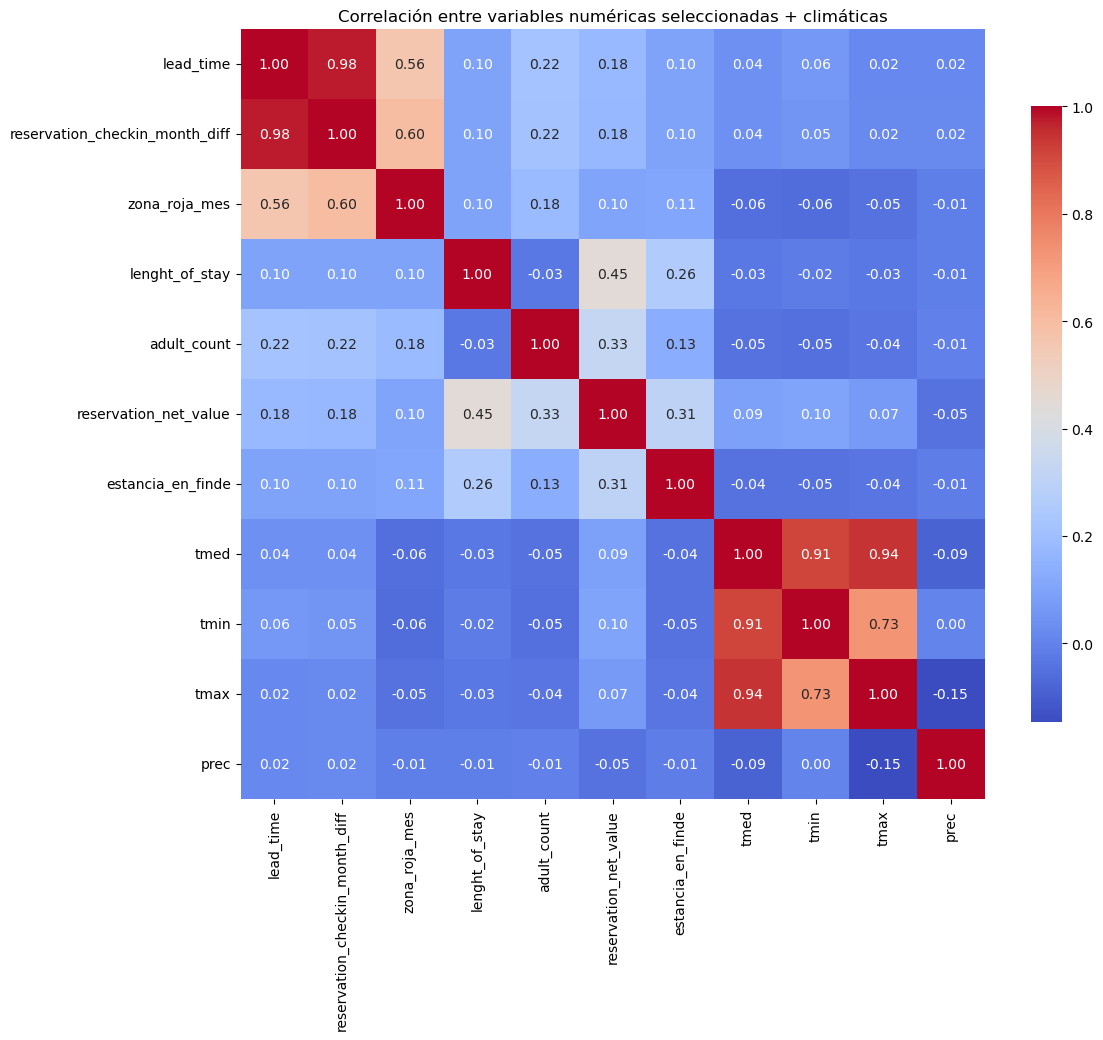

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# Umbral de correlación con el target
umbral = 0.05

# Variables numéricas con |corr| >= 0.05
vars_numericas_filtradas = corr_num[corr_num.abs() >= umbral].index.tolist()

# Agregar explícitamente variables meteorológicas aunque no superen el umbral
vars_adicionales = ["tmed", "tmin", "tmax", "prec"]

# -----------------------------
# Imputar valores faltantes en variables meteorológicas
# Explicación:
# - interpolate(): rellena NaN usando interpolación lineal
# - ffill(): rellena NaN restantes hacia adelante
# - bfill(): rellena NaN restantes hacia atrás
df_junto[vars_adicionales] = df_junto[vars_adicionales].interpolate(method='linear')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='ffill')
df_junto[vars_adicionales] = df_junto[vars_adicionales].fillna(method='bfill')

# Verificar que no queden NaN en las variables meteorológicas
print("Total de NaN en variables meteorológicas después de imputación:")
print(df_junto[vars_adicionales].isna().sum())

# -----------------------------
# Combinar todas las variables para modelado
for var in vars_adicionales:
    if var not in vars_numericas_filtradas:
        vars_numericas_filtradas.append(var)

print("Variables numéricas seleccionadas (|corr| >= 0.05 + variables climáticas):")
print(vars_numericas_filtradas)

# -----------------------------
# Revisar multicolinealidad entre las variables seleccionadas
corr_variables = df_junto[vars_numericas_filtradas].corr()

print("Matriz de correlación entre variables seleccionadas:")
print(corr_variables)

# Heatmap de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_variables, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'shrink': 0.8})
plt.title("Correlación entre variables numéricas seleccionadas + climáticas")
plt.show()

# -----------------------------
# Observaciones sobre la decisión:
# - Variables con mayor correlación con el target:
#   lead_time, reservation_checkin_month_diff, zona_roja_mes, lenght_of_stay
# - Variables con señal débil pero incluidas (|corr| ~ 0.05-0.08):
#   adult_count, reservation_net_value, estancia_en_finde
# - Se incluyen también variables meteorológicas:
#   tmed, tmin, tmax, prec
# - Ninguna variable presenta alta correlación entre sí (>0.7)
# - Decisión final: usar todas las variables seleccionadas con |corr| >= 0.05
#   y las variables climáticas para modelar cancelaciones
# -----------------------------


#### BINARIAS

In [14]:
# 2.  BINARIAS

# 2.1 Detectar columnas binarias (0/1 o True/False)
binarias_vars = []

for columna in df_junto.columns:
    valores_unicos = df_junto[columna].dropna().unique()
    valores_set = set(valores_unicos)
    
    if valores_set.issubset({0, 1}) or valores_set.issubset({True, False}):
        # Excluir el target
        if columna != 'status_bool':
            binarias_vars.append(columna)

print("Variables binarias detectadas:")
print(binarias_vars)

Variables binarias detectadas:
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


In [15]:
# 2.2 Revisar impacto sobre el target
target_col = 'status_bool'

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    print(f'\nColumna: {columna}')
    print(medias)


Columna: zona_roja_mes
zona_roja_mes
0    0.191143
1    0.352428
Name: status_bool, dtype: float64

Columna: estancia_en_festivo
estancia_en_festivo
0    0.229083
1    0.254162
Name: status_bool, dtype: float64

Columna: estancia_en_finde
estancia_en_finde
0    0.198288
1    0.267638
Name: status_bool, dtype: float64


In [16]:
# 2.3 Filtrar variables binarias relevantes
bin_vars_relevantes = []

umbral_diferencia = 0.02  # 2%

for columna in binarias_vars:
    medias = df_junto.groupby(columna)[target_col].mean()
    diferencia = abs(medias.iloc[1] - medias.iloc[0])
    
    if diferencia > umbral_diferencia:
        bin_vars_relevantes.append(columna)

print("\nVariables binarias relevantes (diferencia > 0.02):")
print(bin_vars_relevantes)


# -----------------------------
# Justificación:
# Consideramos relevantes aquellas variables binarias donde la diferencia 
# en la media del target entre los dos grupos supera el 2%. Diferencias pequeñas
# pueden aportar información combinada con otras variables, pero se priorizan
# aquellas con un impacto más claro sobre la cancelación.
# -----------------------------



Variables binarias relevantes (diferencia > 0.02):
['zona_roja_mes', 'estancia_en_festivo', 'estancia_en_finde']


#### CATEGORICAS

In [17]:
# 3.  CATEGÓRICAS 

# 3.1 Detectar columnas categóricas
cat_vars = []

for columna in df_junto.columns:
    if df_junto[columna].dtype.name in ['object', 'category']:
        # Excluir la columna target
        if columna != 'status_bool':
            cat_vars.append(columna)

print("Variables categóricas detectadas:")
print(cat_vars)

Variables categóricas detectadas:
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'asset_type', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Estancia', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


In [18]:
# 3.2 Analizar impacto de variables categóricas sobre el target

target_col = 'status_bool'

for columna in cat_vars:
    # Calcular la media del target por cada categoría
    medias = df_junto.groupby(columna)[target_col].mean().sort_values(ascending=False)
    
    #print(f'\nVariable categórica: {columna}')
    #display(medias.head(10))  # Mostrar las 10 categorías con mayor media

In [19]:
# 3.3 Selección de variables categóricas relevantes

cat_vars_significativas = []

umbral_cat = 0.03  # 3%

for col in cat_vars:
    # Calcular la media del target por cada categoría
    medias_target = df_junto.groupby(col)[target_col].mean()
    
    # Diferencia máxima entre las categorías
    diferencia_max = medias_target.max() - medias_target.min()
    
    # Filtrar si supera el umbral
    if diferencia_max > umbral_cat:
        cat_vars_significativas.append(col)

print("\nVariables categóricas consideradas relevantes (diferencia > 0.03):")
print(cat_vars_significativas)

# Justificación:
# Se consideran relevantes aquellas variables categóricas donde la diferencia
# entre la categoría con mayor y menor media del target ('status_bool')
# supera el 3%. Esto refleja un impacto más claro sobre la probabilidad
# de cancelación, mientras que diferencias menores podrían aportar menos información.



Variables categóricas consideradas relevantes (diferencia > 0.03):
['checkin_month', 'checkin_day', 'origin', 'requested_category', 'asset', 'business_segment', 'rate_type', 'returning_inhabitant', 'libere_community', 'Estacion_Reserva', 'City', 'Reserva_Dia_Semana', 'status', 'fecha', 'indicativo', 'nombre', 'provincia', 'horatmin', 'horatmax', 'horaracha', 'horaHrMax', 'horaHrMin', 'ciudad', 'codigo_ccaa']


### Crear DataFrame Final para Modelado 

In [20]:
# CREAR DATAFRAME FINAL PARA MODELADO

# Unir todas las variables seleccionadas con el target
df_modelado_final = df_junto[
    vars_numericas_filtradas +       # Variables numéricas seleccionadas
    bin_vars_relevantes +            # Variables binarias relevantes
    cat_vars_significativas +        # Variables categóricas relevantes
    [target_col]                     # Target
]

# Verificar dimensiones
print(f"Dimensiones: {df_modelado_final.shape}")


Dimensiones: (51707, 39)


In [21]:
# Variables meteorológicas
vars_meteorologicas = ["tmed", "tmin", "tmax", "prec"]

# Comprobar NaN en df_modelado_final
print("Valores faltantes en variables meteorológicas de df_modelado_final:")
print(df_modelado_final[vars_meteorologicas].isna().sum())

# Total de NaN en todas las variables meteorológicas
print("\nTotal de NaN en todas las variables meteorológicas:", 
      df_modelado_final[vars_meteorologicas].isna().sum().sum())


Valores faltantes en variables meteorológicas de df_modelado_final:
tmed    0
tmin    0
tmax    0
prec    0
dtype: int64

Total de NaN en todas las variables meteorológicas: 0


In [22]:
#Eliminar columnas de tipo fecha ya que no aportaran ningun tipo de informacion para el modelo 
df_modelado_final = df_modelado_final.drop(columns=["fecha", "horatmin", "horatmax", "horaracha", "horaHrMax", "horaHrMin"])

### Formatear el Data Frame (Numericas = Escalar, Categoricas = Dummies)

#### Escalar Variables Numericas

In [23]:
# Función para escalar variables numéricas con MinMaxScaler 
def escalar_numericas(df, columnas_numericas=None):
     """ Escala únicamente las columnas numéricas de un DataFrame usando MinMaxScaler. 
     Parámetros ---------- df : pd.DataFrame DataFrame original. columnas_numericas : 
     list (opcional) Lista de columnas numéricas. Si no se pasa, se detectan automáticamente. Retorna ------- pd.DataFrame DataFrame con columnas numéricas escaladas entre 0 y 1. """ 
     df_copy = df.copy() # Detectar columnas numéricas si no se pasan 
     if columnas_numericas is None: 
        columnas_numericas = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist() 
        scaler = MinMaxScaler() # Escalar solo las numéricas 
        df_copy[columnas_numericas] = scaler.fit_transform(df_copy[columnas_numericas]) 
        return df_copy 
# Aplicar la función al DataFrame 
df_modelado_final = escalar_numericas(df_modelado_final) 
     # Revisar resultado 
print("Primeras filas del DataFrame con variables numéricas escaladas:") 
print(df_modelado_final.head())

Primeras filas del DataFrame con variables numéricas escaladas:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde      tmed      tmin  \
0          0.1               0.015921                1.0  0.480769  0.554348   
1          0.1               0.117788                1.0  0.480769  0.554348   
2          0.2               0.755703                1.0  0.480769  0.554348   
3          0.2               0.186383                1.0  0.480769  0.554348   
4          0.4               0.077025                1.0  0.4

#### Convertir Categoricas a dummies

In [24]:
def convertir_a_dummies(df, columnas_categoricas=None, drop_first=True):
    """
    Convierte columnas categóricas en variables dummies (one-hot encoding).

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame original.
    columnas_categoricas : list (opcional)
        Lista de columnas categóricas. Si no se pasa, se detectan automáticamente.
    drop_first : bool
        Si True, elimina la primera categoría (evita colinealidad).

    Retorna
    -------
    pd.DataFrame
        DataFrame con las columnas categóricas convertidas en dummies.
    """

    df_copy = df.copy()

    # Detectar categóricas si no se pasan
    if columnas_categoricas is None:
        columnas_categoricas = df_copy.select_dtypes(include=['object', 'category']).columns.tolist()

    # Convertir a dummies
    df_dummies = pd.get_dummies(df_copy, columns=columnas_categoricas, drop_first=drop_first)

    return df_dummies

# Aplicar la función al DataFrame escalado
# =========================================================
df_modelado_final = convertir_a_dummies(df_modelado_final) # Revisar resultado 
print("DataFrame final con variables categóricas convertidas a dummies:") 
print(df_modelado_final.head()) 
print(f"Dimensiones finales: {df_modelado_final.shape}")



DataFrame final con variables categóricas convertidas a dummies:
   lead_time  reservation_checkin_month_diff  zona_roja_mes  lenght_of_stay  \
0   0.047461                        0.100000            0.0        0.012658   
1   0.019868                        0.066667            0.0        0.113924   
2   0.120309                        0.166667            0.0        0.075949   
3   0.116998                        0.166667            1.0        0.012658   
4   0.090508                        0.133333            1.0        0.012658   

   adult_count  reservation_net_value  estancia_en_finde      tmed      tmin  \
0          0.1               0.015921                1.0  0.480769  0.554348   
1          0.1               0.117788                1.0  0.480769  0.554348   
2          0.2               0.755703                1.0  0.480769  0.554348   
3          0.2               0.186383                1.0  0.480769  0.554348   
4          0.4               0.077025                1.0  0.

#### Eliminar filas duplicadas:

In [25]:
# Revisar duplicados considerando todas las columnas excepto el target 
duplicados = df_modelado_final.drop(columns=['status_bool']).duplicated(keep=False) 
print("Filas duplicadas:", duplicados.sum()) # Eliminar duplicados exactos en las features 
df_modelado_final = df_modelado_final.drop_duplicates() 
print("Nuevo tamaño del DataFrame:", df_modelado_final.shape)

Filas duplicadas: 4925
Nuevo tamaño del DataFrame: (48817, 122)


In [26]:
# 1. Separar el df y target 
X = df_modelado_final.drop(columns=['status_bool', 'status_checked_out']) # todas las variables excepto el target 
y = df_modelado_final['status_bool'] # target

In [50]:
# -------------------------------
# Función para probar con y sin SMOTE Y APLICANDO PCA O SIN APLICAR PERO CON TRUNCATED SVD (MEJOR PARA SPARSE)


def preparar_datos(X, y, usar_smote=True, aplicar_pca=False, varianza_objetivo=0.9, random_state=42):
    """
    Prepara los datos para modelado.
    
    Parámetros:
    - X: matriz de features (train)
    - y: vector objetivo (train)
    - usar_smote: si True, aplica SMOTETomek al train
    - aplicar_pca: si True, aplica PCA
    - varianza_objetivo: porcentaje de varianza acumulada que queremos conservar con PCA
    - random_state: semilla para reproducibilidad
    
    Retorna:
    - X_preparado, y_preparado, pca_obj (PCA ajustado si se aplica, None si no)
    """
    
    X_prep, y_prep = X.copy(), y.copy()
    
    # Opcional: aplicar SMOTE
    if usar_smote:
        smote_tomek = SMOTETomek(random_state=random_state)
        X_prep, y_prep = smote_tomek.fit_resample(X_prep, y_prep)
        print("Shape original:", X.shape, "Shape balanceado con SMOTE:", X_prep.shape)
    else:
        print("Usando datos sin SMOTE")
    
    # Opcional: aplicar PCA
    pca_obj = None
    if aplicar_pca:
        # Ajustamos PCA con todos los componentes para calcular varianza acumulada
        pca_temp = PCA(random_state=random_state)
        pca_temp.fit(X_prep)
        cum_var = pca_temp.explained_variance_ratio_.cumsum()
        
        # Número de componentes para alcanzar varianza objetivo
        n_comp = np.argmax(cum_var >= varianza_objetivo) + 1
        
        # Ajustamos PCA final con n_comp
        pca_obj = PCA(n_components=n_comp, random_state=random_state)
        X_prep = pca_obj.fit_transform(X_prep)
        
        print(f"PCA aplicado: {n_comp} componentes para explicar {varianza_objetivo*100:.1f}% de varianza")
    
    return X_prep, y_prep, pca_obj

In [52]:
# Import necesario
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

# Llamamos a la función preparar_datos para aplicar SMOTE + PCA
# Puedes ajustar usar_smote=True o False según lo necesites
X_prep, y_prep, pca_obj = preparar_datos(
    X, 
    y, 
    usar_smote=True,       # True para balancear clases, False para no balancear
    aplicar_pca=True,      # True para aplicar PCA
    varianza_objetivo=0.90,
    random_state=42
)

print("Dimensiones de los datos preparados:", X_prep.shape)
print("Dimensiones del vector objetivo:", y_prep.shape)

Shape original: (48817, 121) Shape balanceado con SMOTE: (75098, 121)
PCA aplicado: 32 componentes para explicar 90.0% de varianza
Dimensiones de los datos preparados: (75098, 32)
Dimensiones del vector objetivo: (75098,)


### Train / Test

In [53]:
# ------------------------------------------
# Paso 2: División en Train/Test
# ------------------------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_prep, y_prep,
    test_size=0.2,
    random_state=42,
    stratify=y_prep
)

print(f"Tamaño X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Tamaño y_train: {y_train.shape}, y_test: {y_test.shape}")


Tamaño X_train: (60078, 32), X_test: (15020, 32)
Tamaño y_train: (60078,), y_test: (15020,)


### ENCONTRAR UMBRAL:

In [56]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score

def encontrar_mejor_umbral(
    model,
    X_val,
    y_val,
    metrica="f1",               # <--- este argumento
    thresholds=np.arange(0.1, 0.9, 0.01)
):
    """
    Encuentra el mejor umbral según la métrica elegida (f1, recall o precision)
    """
    y_proba = model.predict_proba(X_val)[:, 1]

    mejor_umbral = 0.5
    mejor_score = 0

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        if metrica == "f1":
            score = f1_score(y_val, y_pred)
        elif metrica == "recall":
            score = recall_score(y_val, y_pred)
        elif metrica == "precision":
            score = precision_score(y_val, y_pred)
        else:
            raise ValueError("Métrica no válida: elige 'f1', 'recall' o 'precision'")

        if score > mejor_score:
            mejor_score = score
            mejor_umbral = t

    return mejor_umbral, mejor_score


### FUNCION PARA EVALUAR MODELOS:

In [57]:
# ------------------------------------------
# Paso 3: Función genérica para evaluar modelos
# ------------------------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd

def evaluar_modelo(modelo, X_val, y_val, nombre_modelo="Modelo"):
    """
    Evalúa un modelo de clasificación:
    - Busca mejor umbral según F1-score
    - Calcula métricas y ROC-AUC
    - Muestra matriz de confusión y curva ROC
    """
    # Probabilidades de clase positiva
    y_proba = modelo.predict_proba(X_val)[:,1]
    
    # Buscar mejor umbral
    best_threshold, best_f1 = encontrar_mejor_umbral(modelo, X_val, y_val, metrica="f1")
    
    # Predicciones con el mejor umbral
    y_pred_opt = (y_proba >= best_threshold).astype(int)
    
    # Métricas
    accuracy = accuracy_score(y_val, y_pred_opt)
    precision = precision_score(y_val, y_pred_opt)
    recall = recall_score(y_val, y_pred_opt)
    f1 = f1_score(y_val, y_pred_opt)
    roc_auc = roc_auc_score(y_val, y_proba)
    
    # Matriz de confusión
    cm = confusion_matrix(y_val, y_pred_opt)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    
    # Plot
    fig, axes = plt.subplots(1,2, figsize=(14,5))
    disp.plot(cmap=plt.cm.Blues, ax=axes[0], colorbar=False, values_format='d')
    axes[0].set_title(f"Matriz de Confusión - {nombre_modelo}")
    
    axes[1].plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--')
    axes[1].set_xlim([0,1])
    axes[1].set_ylim([0,1.05])
    axes[1].set_xlabel('FPR')
    axes[1].set_ylabel('TPR')
    axes[1].set_title(f'Curva ROC - {nombre_modelo}')
    axes[1].legend(loc='lower right')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Crear DataFrame de métricas
    metricas_df = pd.DataFrame({
        "Accuracy": [accuracy],
        "Precision": [precision],
        "Recall": [recall],
        "F1-score": [f1],
        "ROC-AUC": [roc_auc],
        "Threshold": [best_threshold]
    }, index=[nombre_modelo])
    
    return metricas_df


# REGRESION LOGISTICA

BASELINE

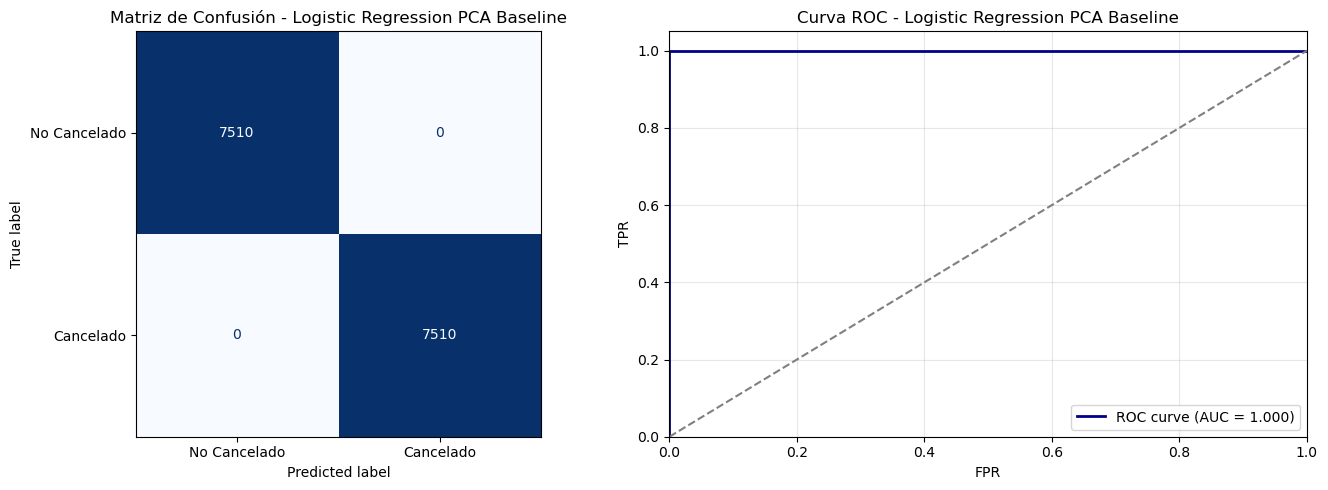

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Threshold
Logistic Regression PCA Baseline,1.0,1.0,1.0,1.0,1.0,0.1


In [58]:
from sklearn.linear_model import LogisticRegression

# Instanciar modelo
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X_train, y_train)

# Evaluar
metricas_logreg = evaluar_modelo(logreg, X_test, y_test, nombre_modelo="Logistic Regression PCA Baseline")
metricas_logreg


GRIDSEARCH SIN SMOTE

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'C': 0.01, 'penalty': 'l1'}


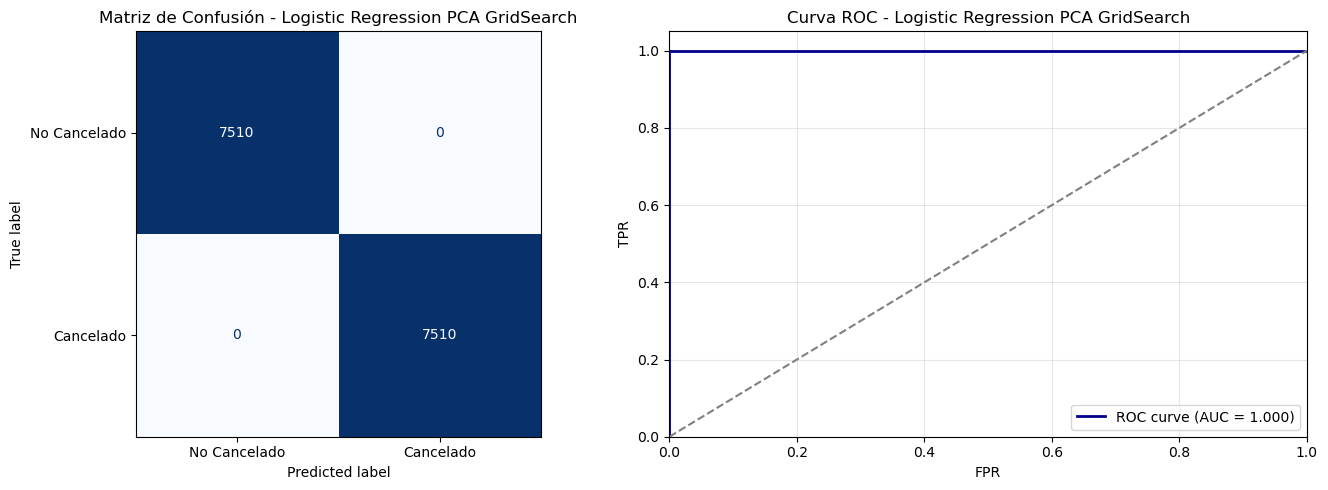

,Accuracy,Precision,Recall,F1-score,ROC-AUC,Threshold
Logistic Regression PCA GridSearch,1.0,1.0,1.0,1.0,1.0,0.16


In [59]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# Definir grid
param_grid = {'C':[0.01,0.1,1,10,100],'penalty':['l1','l2']}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000, solver='liblinear'),
                            param_grid=param_grid,
                            scoring=scorer,
                            cv=cv,
                            n_jobs=-1,
                            verbose=1)
grid_logreg.fit(X_train, y_train)

logreg_best = grid_logreg.best_estimator_
print("Mejores parámetros:", grid_logreg.best_params_)

metricas_logreg_grid = evaluar_modelo(logreg_best, X_test, y_test, nombre_modelo="Logistic Regression PCA GridSearch")
metricas_logreg_grid
